In [1]:
import os
import numpy as np
import random
from shutil import copyfile, rmtree
from tqdm import tqdm
import time  # For training time tracking

import tensorflow as tf
from tensorflow.keras import Model, layers, callbacks
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# ==================== CONFIG ====================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 60
INITIAL_LR = 1e-4
LABEL_SMOOTHING = 0.1

dataset_dir = '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9'
base_dir = '/kaggle/working/colon_split'

# ==================== SPLIT CLEANUP ====================
if os.path.exists(base_dir):
    rmtree(base_dir)

# ==================== SPLIT ====================
splits = ['train', 'val', 'test']
class_names = os.listdir(dataset_dir)

for split in splits:
    for class_name in class_names:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

for class_name in class_names:
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    random.shuffle(image_list)
    n_total = len(image_list)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)

    split_sets = {
        'train': image_list[:n_train],
        'val': image_list[n_train:n_train + n_val],
        'test': image_list[n_train + n_val:]
    }

    for split, split_files in split_sets.items():
        for img in tqdm(split_files, desc=f'{class_name} - {split}'):
            src = os.path.join(dataset_dir, class_name, img)
            dst = os.path.join(base_dir, split, class_name, img)
            copyfile(src, dst)

# ==================== DATA LOADERS ====================
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_generator = datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
test_generator = datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)

# ==================== MODEL ====================
def build_xception_model():
    base_model = Xception(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=l2(1e-4))(x)

    model = Model(inputs, outputs)
    return model

model = build_xception_model()

# ==================== COMPILE ====================
loss_fn = CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)
model.compile(optimizer=Adam(learning_rate=INITIAL_LR),
              loss=loss_fn,
              metrics=['accuracy'])

# ==================== CALLBACKS ====================
checkpoint_cb = callbacks.ModelCheckpoint(
    'xception.keras', monitor='val_accuracy', save_best_only=True, verbose=1
)
earlystop_cb = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=8, restore_best_weights=True
)
reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-6
)

# ==================== TRAIN (WITH TIME TRACKING) ====================
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb],
    verbose=1
)

end_time = time.time()
total_train_time = end_time - start_time
epoch_count = len(history.history['loss'])
avg_epoch_time = total_train_time / epoch_count

print(f"\n🕒 Total training time: {total_train_time:.2f} seconds")
print(f"⏱️ Average time per epoch: {avg_epoch_time:.2f} seconds")

# ==================== EVALUATION ====================
model.load_weights("xception.keras")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

2025-08-18 14:32:43.182382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755527563.514718      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755527563.613705      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
1_ulcerative_colitis - test: 100%|██████████| 225/225 [00:01<00:00, 202.18it/s]


Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.


I0000 00:00:1755527615.852741      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1755527615.853461      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60


I0000 00:00:1755527626.090362     113 service.cc:148] XLA service 0x785ba8002180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755527626.091967     113 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1755527626.091992     113 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1755527627.092216     113 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/132 ━━━━━━━━━━━━━━━━━━━━ 35:33 16s/step - accuracy: 0.2812 - loss: 1.5782

I0000 00:00:1755527635.910639     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.5645 - loss: 1.1685
Epoch 1: val_accuracy improved from -inf to 0.88889, saving model to xception.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 47s 232ms/step - accuracy: 0.5655 - loss: 1.1670 - val_accuracy: 0.8889 - val_loss: 0.6626 - learning_rate: 1.0000e-04
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8294 - loss: 0.7381
Epoch 2: val_accuracy improved from 0.88889 to 0.90556, saving model to xception.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 22s 162ms/step - accuracy: 0.8296 - loss: 0.7379 - val_accuracy: 0.9056 - val_loss: 0.6145 - learning_rate: 1.0000e-04
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8863 - loss: 0.6579
Epoch 3: val_accuracy improved from 0.90556 to 0.92889, saving model to xception.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 23s 170ms/step - accuracy: 0.8863 - loss: 0.6579 - val_accuracy: 0.9289 - val_loss: 0.5889 - learning_rate: 1.0000e-04
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 14

29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 233ms/step


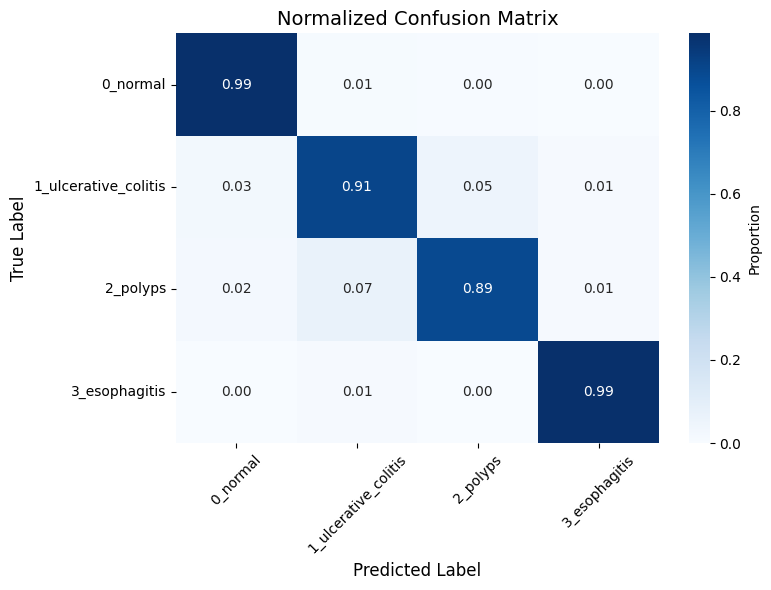

Classification Report:
                      precision    recall  f1-score   support

            0_normal       0.95      0.99      0.97       225
1_ulcerative_colitis       0.91      0.91      0.91       225
            2_polyps       0.94      0.89      0.92       225
       3_esophagitis       0.97      0.99      0.98       225

            accuracy                           0.94       900
           macro avg       0.94      0.94      0.94       900
        weighted avg       0.94      0.94      0.94       900



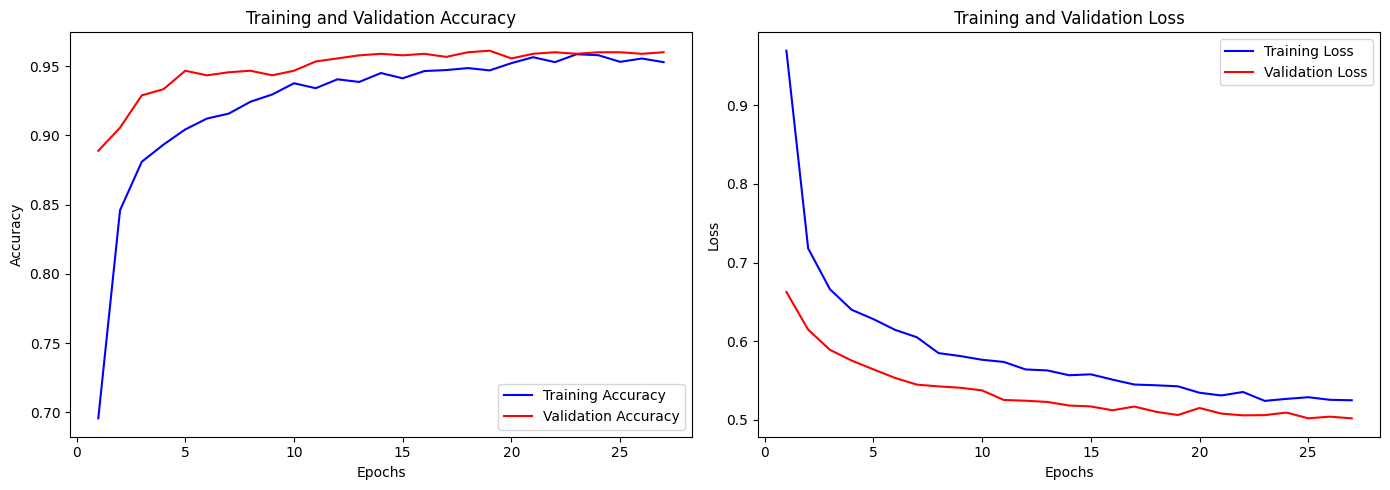

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class labels
class_labels = list(test_generator.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row
class_labels = list(test_generator.class_indices.keys())

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Proportion'})

plt.title("Normalized Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============ CLASSIFICATION REPORT ============
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# ============ ACCURACY & LOSS CURVES ============
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)